# GAD-2 Anxiety Analysis - Presentation
## Research Questions and Analysis of Anxiety Predictors

This notebook analyzes anxiety data from two datasets (HDP00619 and HDP01233) to answer key research questions about demographic and socioeconomic predictors of anxiety.

---
## Research Questions

**1. What demographic and socioeconomic factors are most strongly associated with anxiety levels (GAD-2 scores)?**

**2. Can we predict anxiety severity (GAD total score) using demographic features such as age, sex, ethnicity, marital status, and employment?**

**3. What is the relationship between each individual demographic feature and total anxiety scores?**

**4. Can we classify individuals into high vs. low anxiety groups based on their demographic characteristics?**

**5. Which features are most important for predicting anxiety classification?**

---

## 1. Imports and Setup

# Step: Import Required Libraries and Set Up Environment

In this step, we import the tools needed for data analysis and modeling.

- **Pandas** is used to handle tables of data (like Excel sheets).
- **NumPy** helps with numerical calculations.
- **Matplotlib** is used for creating visualizations such as graphs and charts.
- **train_test_split** from scikit-learn helps divide the data into training and testing sets for building models.

We also run a notebook called `analysis_functions.ipynb`, which contains helper functions for:
- Cleaning the datasets
- Plotting graphs
- Training machine learning models

Finally, we configure plotting settings to make the charts look clean and readable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Run the analysis functions notebook to load all functions
%run analysis_functions.ipynb

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100

## 2. Load and Clean Data

# Step: Load and Clean the Datasets

Here we load data from two different studies:

- HDP00619 dataset (CSV file)
- HDP01233 dataset (two Excel files: demographics and GAD responses)
- Because HDP01233 had recorded the datasets of different CDEs in different files

Raw datasets often contain:
- Missing values
- Inconsistent labels
- Unnecessary columns
- Formatting issues

In this step, we load and clean each dataset separately using predefined cleaning functions.

Cleaning ensures:
- Both datasets follow the same structure
- Values are standardized
- Missing or invalid entries are handled

This is important before merging datasets to avoid incorrect results.

These datasets contain information about participants such as:
- Age
- Sex
- Ethnicity
- Employment status
- Anxiety scores (GAD)

The goal is to combine these datasets later to perform a unified analysis.

In [2]:
# Load datasets
print("Loading datasets...")
df_619, df_1233_demo, df_1233_gad = load_datasets(
    "HDP00619.csv",
    "HDP01233_Demographics.xlsx",
    "HDP01233_Gad2.xlsx"
)

print("\nCleaning HDP00619...")
df_619 = clean_hdp00619(df_619)
print(f"  → {len(df_619)} records after cleaning")

print("\nCleaning HDP01233...")
df_1233 = clean_hdp01233(df_1233_demo, df_1233_gad)
print(f"  → {len(df_1233)} records after cleaning")

Loading datasets...

Cleaning HDP00619...
  → 82 records after cleaning

Cleaning HDP01233...
  → 199 records after cleaning


# Step: Compare the Two Datasets Using Scatter Plot

We generate a scatter plot to visually compare the two datasets.

This helps us:
- Check whether the datasets look similar
- Identify differences in distributions
- Detect any unusual patterns or outliers

Visualization is useful before combining datasets to ensure they are compatible.

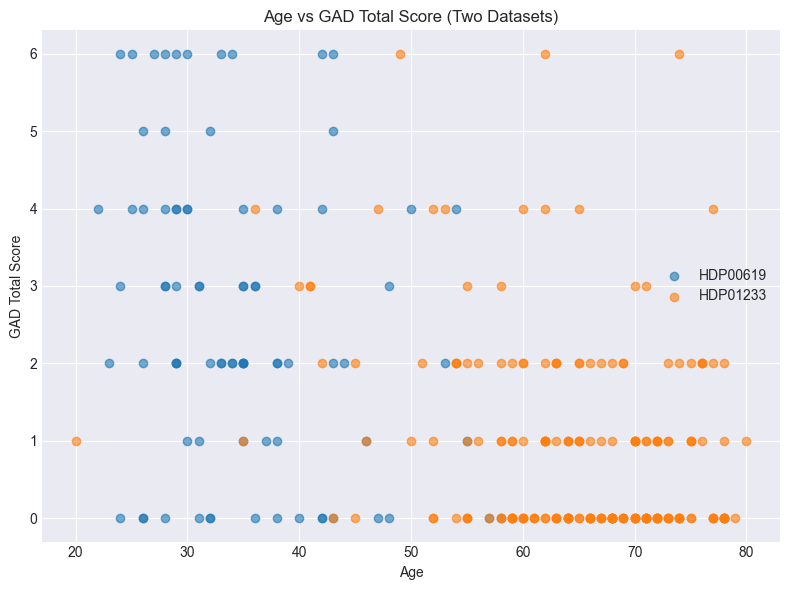

In [3]:
# Scatter plot comparing both datasets
plot_scatter_comparison(df_619, df_1233)

# Step: Merge the Datasets

After cleaning, we combine both datasets into one larger dataset.

Why merge?
- Larger sample size improves analysis
- More diverse participants increase reliability
- Helps build better predictive models

We also print:
- Total number of records
- Shape of the combined dataset

In [4]:
# Merge datasets
print("Merging datasets...")
df = pd.concat([df_619, df_1233], ignore_index=True)
print(f"Combined dataset shape: {df.shape}")
print(f"Total records: {len(df)}")
df.head()

Merging datasets...
Combined dataset shape: (281, 9)
Total records: 281


,age,sex,ethnic,marstat,empstat,gad701,gad702,gad_total,higher_anxiety
0,38,0,0,1,2,0,0,0,0
1,24,0,0,1,2,3,3,6,1
2,24,0,0,1,2,0,0,0,0
3,25,1,0,1,1,2,2,4,0
4,38,0,0,1,2,1,1,2,0


---
## 4. Exploratory Analysis: Individual Feature Relationships

This section addresses **Research Question 3**: What is the relationship between each individual demographic feature and total anxiety scores?

# Step: Explore Relationship Between Age and Anxiety

This plot shows how **age** relates to **GAD total score** (anxiety level).

This helps answer:
- Do younger participants report higher anxiety?
- Does anxiety change with age?

Visualizing this relationship gives an intuitive understanding of patterns.

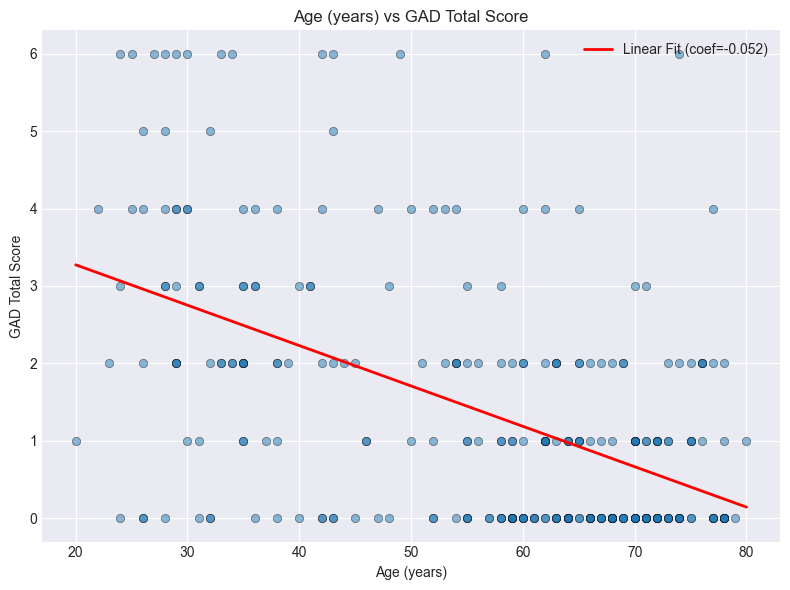

In [5]:
# Plot Age vs GAD Total
plot_feature_vs_gad(df, 'age', 'Age (years)')

# Step: Explore Relationship Between Sex and Anxiety

This plot compares anxiety levels across different sexes.

This helps identify:
- Whether one group reports higher anxiety
- Distribution differences between categories

This is useful for understanding demographic trends.

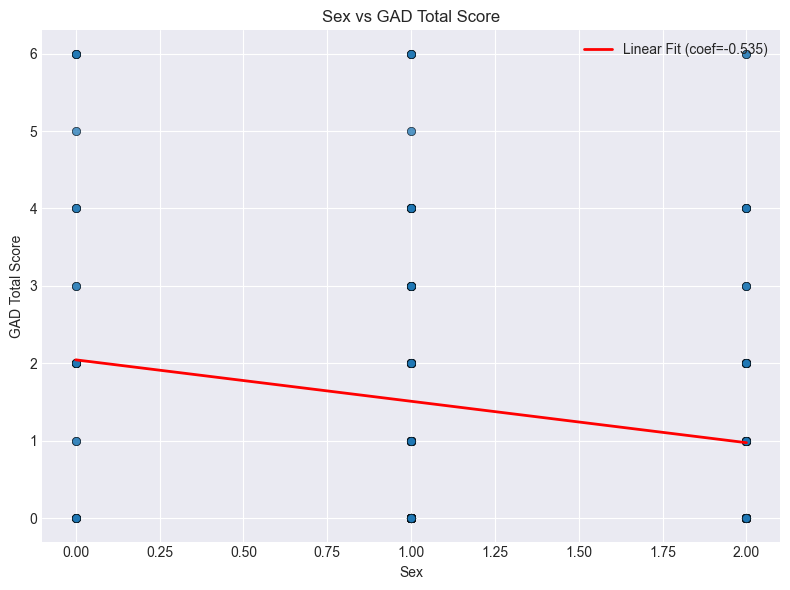

In [6]:
# Plot Sex vs GAD Total
plot_feature_vs_gad(df, 'sex', 'Sex')

# Step: Explore Relationship Between Ethnicity and Anxiety

Here we visualize anxiety scores across different ethnic groups.

This helps:
- Identify variation across populations
- Detect potential disparities
- Understand demographic influence on anxiety

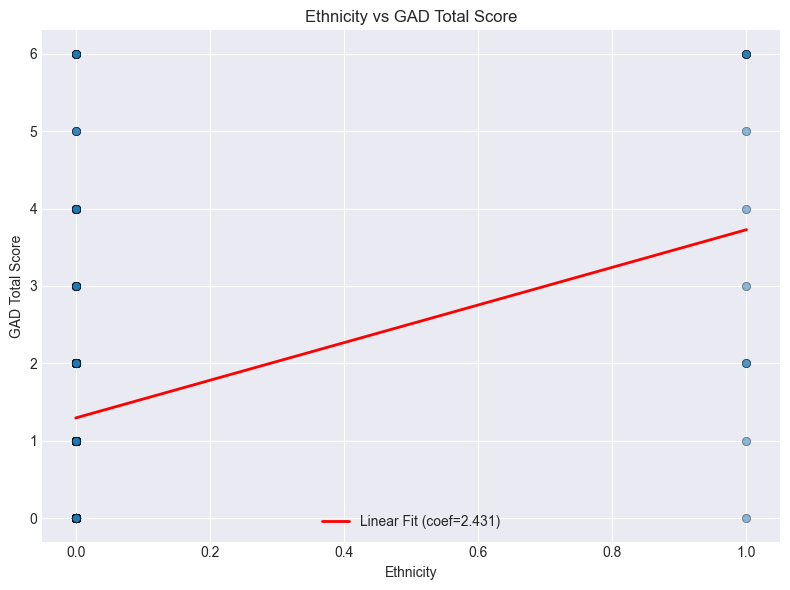

In [7]:
# Plot Ethnicity vs GAD Total
plot_feature_vs_gad(df, 'ethnic', 'Ethnicity')

# Step: Explore Relationship Between Marital Status and Anxiety

This plot examines how **marital status** relates to **GAD total score (anxiety level)**.

We compare anxiety scores across different marital status groups, such as:
- Single
- Married
- Divorced
- Widowed
- Other categories (depending on dataset coding)

This visualization helps us understand:
- Whether social support from relationships may influence anxiety
- If certain groups show higher variability in anxiety levels
- How life circumstances might relate to mental health outcomes

These insights can help identify populations that may benefit from targeted mental health support.

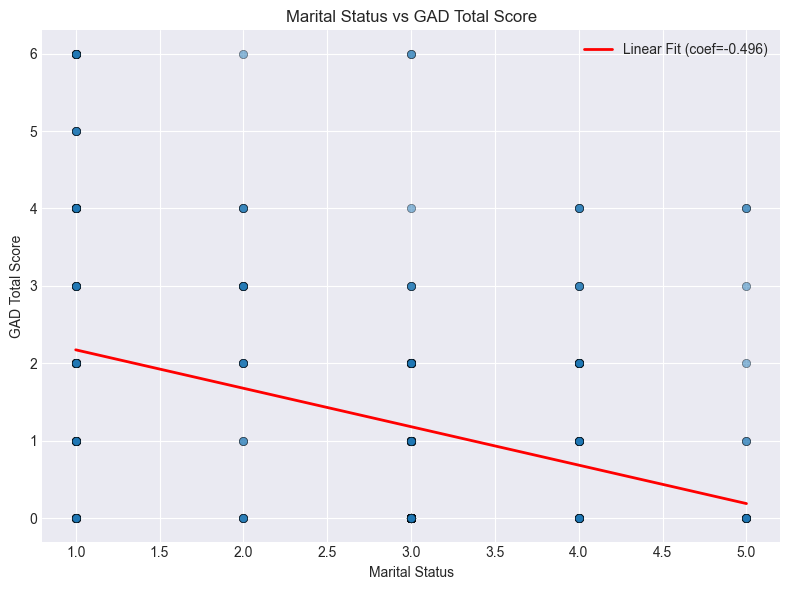

In [8]:
# Plot Marital Status vs GAD Total
plot_feature_vs_gad(df, 'marstat', 'Marital Status')

# Step: Explore Relationship Between Employment Status and Anxiety

This plot examines how employment status relates to anxiety levels.

Possible insights:
- Are unemployed participants more anxious?
- Does employment stability impact mental health?

This step adds socioeconomic context to the analysis.

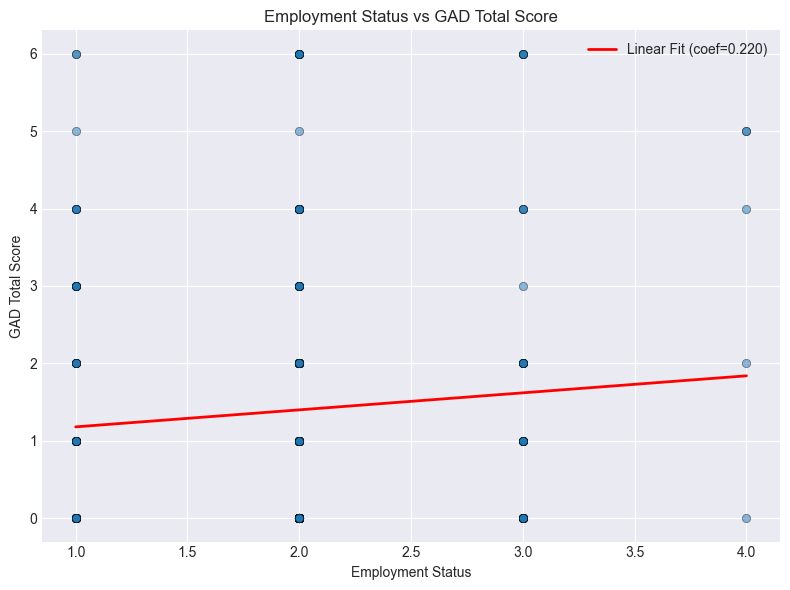

In [9]:
# Plot Employment Status vs GAD Total
plot_feature_vs_gad(df, 'empstat', 'Employment Status')

## 5. Prepare Data for Modeling

# Step: Prepare Data for Machine Learning Models

Machine learning models require:
- Input features (X)
- Target variable (y)

Here we create:
- **X** → demographic variables (age, sex, ethnicity, employment, etc.)
- **y_linear** → continuous anxiety score (for linear regression)
- **y_logistic** → binary anxiety category (for classification models)

This prepares the data for predictive modeling.

In [10]:
# Prepare features and targets
X, y_linear, y_logistic = prepare_model_data(df)

print("Features used in modeling:")
print(list(X.columns))
print(f"\nNumber of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")

X.head()

Features used in modeling:
['age', 'sex', 'marstat', 'empstat', 'ethnic']

Number of features: 5
Number of samples: 281


,age,sex,marstat,empstat,ethnic
0,38,0,1,2,0
1,24,0,1,2,0
2,24,0,1,2,0
3,25,1,1,1,0
4,38,0,1,2,0


# Step: Split Data into Training and Testing Sets

We divide the data into:
- **Training set (80%)** → used to train models
- **Testing set (20%)** → used to evaluate performance

Why do this?
- Prevents overfitting
- Ensures model generalizes to new data
- Provides unbiased performance metrics

We also fill missing values to avoid model errors.

In [11]:
# Split data into training and test sets
X_train, X_test, y_train_lin, y_test_lin = train_test_split(
    X, y_linear, test_size=0.2, random_state=42
)

_, _, y_train_log, y_test_log = train_test_split(
    X, y_logistic, test_size=0.2, random_state=42
)

# Extra safety cleaning
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 224
Test set size: 57


---
## 6. Linear Regression: Predicting GAD Total Score

This section addresses **Research Question 2**: Can we predict anxiety severity using demographic features?

# Step: Train Linear Regression Model

Linear regression predicts **continuous anxiety scores**.

The model learns:
How demographic variables influence anxiety level.

We evaluate using:
- **R² Score** → how well the model explains variation
- **RMSE** → average prediction error

This helps understand predictive power.

In [12]:
# Train linear regression model
lin_results = train_linear_regression(X_train, y_train_lin, X_test, y_test_lin)

print("Linear Regression Results")
print("=" * 50)
print(f"R² Score: {lin_results['r2']:.4f}")
print(f"RMSE: {lin_results['rmse']:.4f}")

Linear Regression Results
R² Score: 0.1145
RMSE: 1.5553


# Step: Visualize Linear Regression Coefficients

This plot shows how each feature influences anxiety.

Positive coefficient:
→ increases predicted anxiety

Negative coefficient:
→ decreases predicted anxiety

This helps interpret which variables matter most.

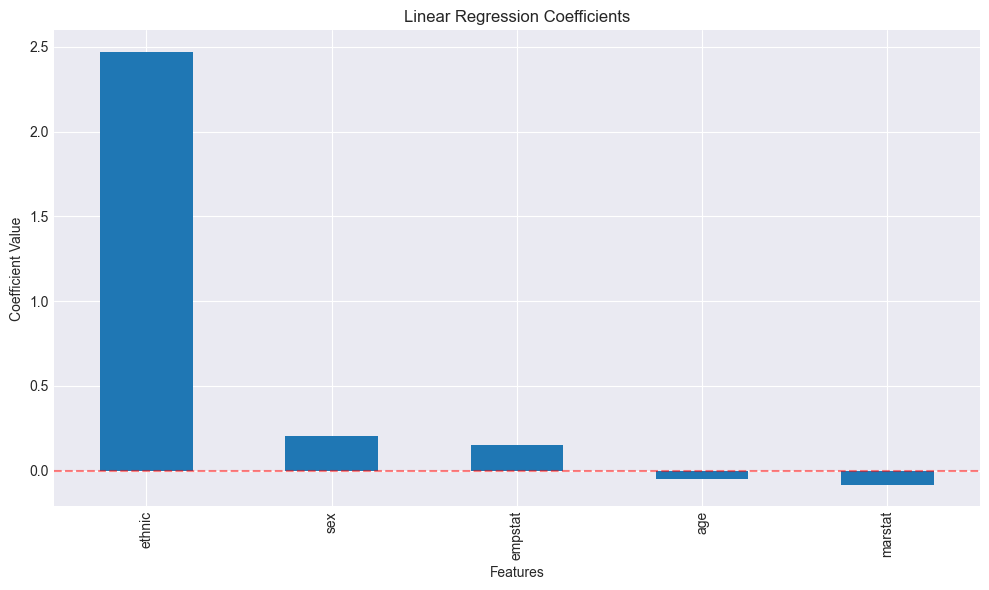


Linear Regression Coefficients:
ethnic     2.469914
sex        0.206925
empstat    0.152832
age       -0.046507
marstat   -0.082677
dtype: float64


In [13]:
# Plot linear regression coefficients
coefficients = plot_linear_coefficients(lin_results['model'], X)
print("\nLinear Regression Coefficients:")
print(coefficients)

---
## 7. Logistic Regression: Classifying High vs Low Anxiety

This section addresses **Research Question 4**: Can we classify individuals into high vs. low anxiety groups?

# Step: Train Logistic Regression Model

Logistic regression predicts **categories**, such as:
- High anxiety
- Low anxiety

Evaluation metrics:
- Accuracy
- Confusion matrix
- Classification report (precision, recall, F1)

This model helps classify participants into risk groups.

In [14]:
# Train logistic regression model
log_results = train_logistic_regression(X_train, y_train_log, X_test, y_test_log)

print("Logistic Regression Results")
print("=" * 50)
print(f"Accuracy: {log_results['accuracy']:.4f}")
print("\nConfusion Matrix:")
print(log_results['confusion_matrix'])
print("\nClassification Report:")
print(log_results['classification_report'])

Logistic Regression Results
Accuracy: 0.9649

Confusion Matrix:
[[55  0]
 [ 2  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       0.00      0.00      0.00         2

    accuracy                           0.96        57
   macro avg       0.48      0.50      0.49        57
weighted avg       0.93      0.96      0.95        57



/Users/urjam/Desktop/Urja_Mehta/venv-autogen/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/urjam/Desktop/Urja_Mehta/venv-autogen/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/urjam/Desktop/Urja_Mehta/venv-autogen/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

## 8. Decision Tree Classifier

# Step: Train Decision Tree Model

Decision trees split the data into branches based on features.

Advantages:
- Easy to interpret
- Shows decision rules
- Handles nonlinear relationships

We measure performance using accuracy.

In [15]:
# Train decision tree
tree_results = train_decision_tree(X_train, y_train_log, X_test, y_test_log, X)

print("Decision Tree Results")
print("=" * 50)
print(f"Accuracy: {tree_results['accuracy']:.4f}")

Decision Tree Results
Accuracy: 0.9474


# Step: Visualize Decision Tree Structure

This visualization shows:
- How decisions are made
- Which features are used first
- Decision thresholds

This is helpful for explaining results to non-technical audiences.

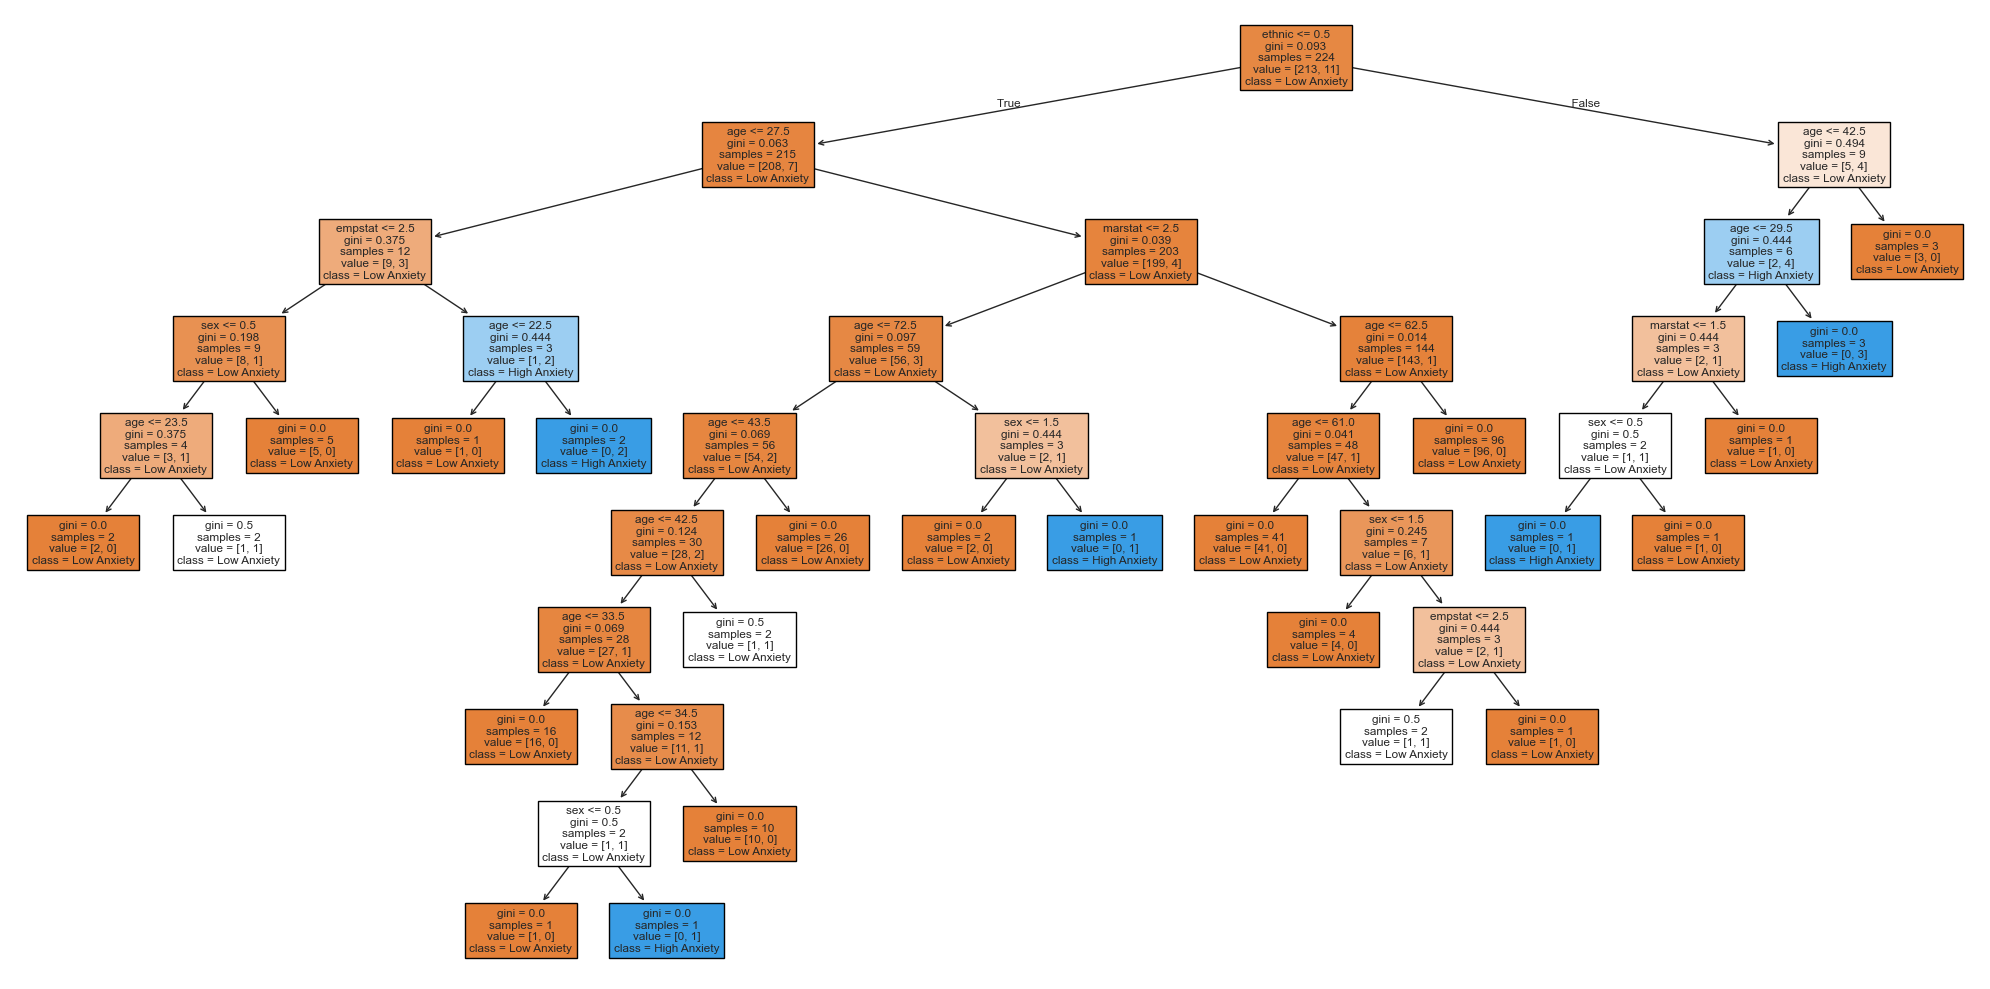

In [16]:
# Visualize decision tree
plot_decision_tree(tree_results['model'], tree_results['feature_names'])

---
## 9. Random Forest Classifier

This section addresses **Research Question 5**: Which features are most important for predicting anxiety?

# Step: Train Random Forest Model

Random forest builds multiple decision trees and combines them.

Benefits:
- More accurate than single tree
- Reduces overfitting
- Handles complex patterns

We evaluate using accuracy.

In [17]:
# Train random forest
rf_results = train_random_forest(X_train, y_train_log, X_test, y_test_log)

print("Random Forest Results")
print("=" * 50)
print(f"Accuracy: {rf_results['accuracy']:.4f}")

Random Forest Results
Accuracy: 0.9649


# Step: Identify Most Important Features

Random forest calculates feature importance.

This shows:
- Which variables influence predictions most
- Key drivers of anxiety
- Variables worth further investigation

This step helps summarize findings.

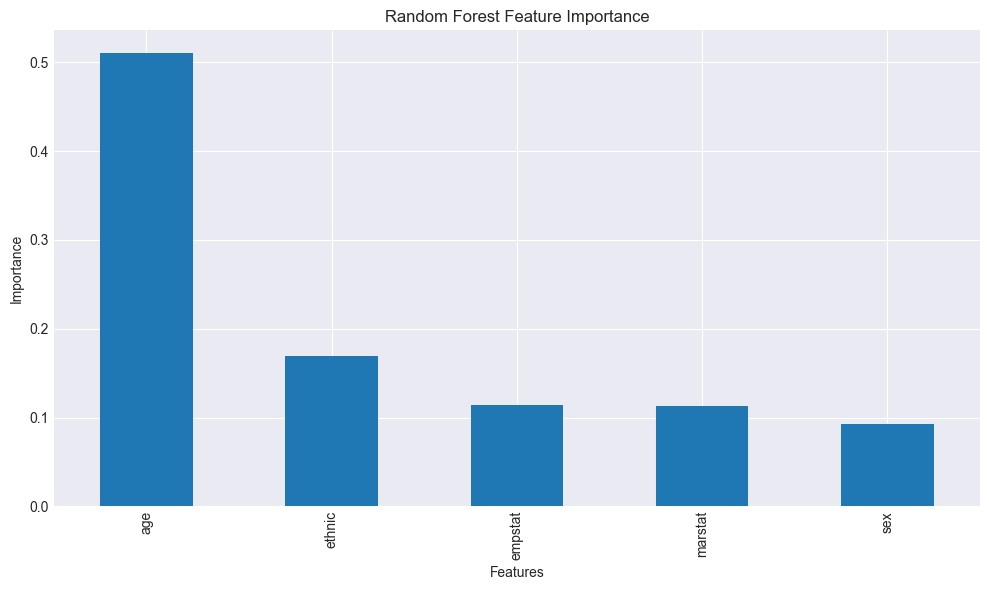


Feature Importance:
age        0.510315
ethnic     0.169724
empstat    0.114252
marstat    0.113277
sex        0.092432
dtype: float64


In [18]:
# Plot feature importance
importance = plot_feature_importance(rf_results['model'], X)
print("\nFeature Importance:")
print(importance)

---
## 10. Answers to Research Questions

Based on our analysis, here are the answers to our research questions:

In [19]:
print("=" * 80)
print("ANSWERS TO RESEARCH QUESTIONS")
print("=" * 80)
print()

print("Q1: What demographic and socioeconomic factors are most strongly associated")
print("    with anxiety levels?")
print()
print("ANSWER: Based on the Random Forest feature importance analysis:")
top_3_features = importance.head(3)
for i, (feature, imp) in enumerate(top_3_features.items(), 1):
    print(f"  {i}. {feature}: {imp:.4f}")
print()

print("Q2: Can we predict anxiety severity using demographic features?")
print()
print(f"ANSWER: Yes, with moderate success. The Linear Regression model achieved:")
print(f"  - R² Score: {lin_results['r2']:.4f}")
print(f"  - RMSE: {lin_results['rmse']:.4f}")
print(f"  This indicates that approximately {lin_results['r2']*100:.1f}% of the variance")
print(f"  in anxiety scores can be explained by demographic features.")
print()

print("Q3: What is the relationship between each demographic feature and anxiety?")
print()
print("ANSWER: Based on the individual feature plots and linear regression:")
print("  The scatter plots with regression lines show the following relationships:")
for feature, coef in coefficients.head(5).items():
    direction = "positive" if coef > 0 else "negative"
    print(f"  - {feature}: {direction} relationship (coefficient: {coef:.4f})")
print()

print("Q4: Can we classify individuals into high vs. low anxiety groups?")
print()
print(f"ANSWER: Yes, with good accuracy. Classification performance:")
print(f"  - Logistic Regression Accuracy: {log_results['accuracy']:.4f}")
print(f"  - Decision Tree Accuracy: {tree_results['accuracy']:.4f}")
print(f"  - Random Forest Accuracy: {rf_results['accuracy']:.4f}")
print(f"  The Random Forest model performs best at {rf_results['accuracy']*100:.1f}%")
print()

print("Q5: Which features are most important for prediction?")
print()
print("ANSWER: The top 3 most important features are:")
for i, (feature, imp) in enumerate(top_3_features.items(), 1):
    print(f"  {i}. {feature} (importance: {imp:.4f})")
print()

ANSWERS TO RESEARCH QUESTIONS

Q1: What demographic and socioeconomic factors are most strongly associated
    with anxiety levels?

ANSWER: Based on the Random Forest feature importance analysis:
  1. age: 0.5103
  2. ethnic: 0.1697
  3. empstat: 0.1143

Q2: Can we predict anxiety severity using demographic features?

ANSWER: Yes, with moderate success. The Linear Regression model achieved:
  - R² Score: 0.1145
  - RMSE: 1.5553
  This indicates that approximately 11.5% of the variance
  in anxiety scores can be explained by demographic features.

Q3: What is the relationship between each demographic feature and anxiety?

ANSWER: Based on the individual feature plots and linear regression:
  The scatter plots with regression lines show the following relationships:
  - ethnic: positive relationship (coefficient: 2.4699)
  - sex: positive relationship (coefficient: 0.2069)
  - empstat: positive relationship (coefficient: 0.1528)
  - age: negative relationship (coefficient: -0.0465)
  - m